# Math for Machine Learning — Linear Algebra Week 1
## Systems of Linear Equations, Matrices, Determinants, Singularity, and Linear Dependence

This notebook turns the Week 1 PDF content into beginner-friendly Jupyter Notebook code examples.

Topics covered:

1. Systems of linear equations from word problems
2. Matrix form of a system
3. Solving systems with NumPy
4. Graphing equations as lines
5. Singular vs. non-singular matrices
6. Determinants of 2×2 and 3×3 matrices
7. Linear dependence and independence
8. Rank and row reduction ideas

> Educational attribution: based on DeepLearning.AI Math for Machine Learning, Linear Algebra Week 1 materials.

## 0. Setup

We will use:

- `numpy` for matrix calculations
- `matplotlib` for graphing lines
- `sympy` for exact symbolic row reduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import sympy as sp
    sympy_available = True
except ImportError:
    sympy_available = False
    print("SymPy is not installed. Row-reduction examples will be skipped.")

# 1. Turning Sentences into Equations

Example from the lesson:

- Day 1: You bought an apple and a banana and they cost $10.
- Day 2: You bought an apple and two bananas and they cost $12.

Let:

\[
a = \text{price of one apple}
\]

\[
b = \text{price of one banana}
\]

Then the system is:

\[
a + b = 10
\]

\[
a + 2b = 12
\]

In [2]:
# Coefficient matrix
A = np.array([
    [1, 1],
    [1, 2]
], dtype=float)

# Constant vector
y = np.array([10, 12], dtype=float)

solution = np.linalg.solve(A, y)

a, b = solution
print(f"Apple price:  ${a:.2f}")
print(f"Banana price: ${b:.2f}")

Apple price:  $8.00
Banana price: $2.00


## Explanation

The first equation says:

\[
a+b=10
\]

The second equation says:

\[
a+2b=12
\]

Subtract the first equation from the second equation:

\[
(a+2b)-(a+b)=12-10
\]

\[
b=2
\]

Then substitute back:

\[
a+2=10
\]

\[
a=8
\]

So an apple costs **$8** and a banana costs **$2**.

# 2. Matrix Form of a System

A system like this:

\[
\begin{cases}
5x + 3y + 5z = 6 \\
7x + 2y + 8z = 17 \\
4x + 0y + 3z = 8
\end{cases}
\]

can be written in matrix form as:

\[
A\mathbf{x}=\mathbf{b}
\]

where

\[
A=
\begin{bmatrix}
5&3&5\\
7&2&8\\
4&0&3
\end{bmatrix},
\quad
\mathbf{x}=\begin{bmatrix}x\\y\\z\end{bmatrix},
\quad
\mathbf{b}=\begin{bmatrix}6\\17\\8\end{bmatrix}
\]

In [3]:
A = np.array([
    [5, 3, 5],
    [7, 2, 8],
    [4, 0, 3]
], dtype=float)

b = np.array([6, 17, 8], dtype=float)

x = np.linalg.solve(A, b)
print("Solution [x, y, z] =", x)

Solution [x, y, z] = [-0.2173913  -2.56521739  2.95652174]


# 3. Graphing a System as Lines

For two variables, each linear equation represents a **line**.

Example:

\[
a+b=10
\]

\[
a+2b=12
\]

The solution is the point where the two lines intersect.

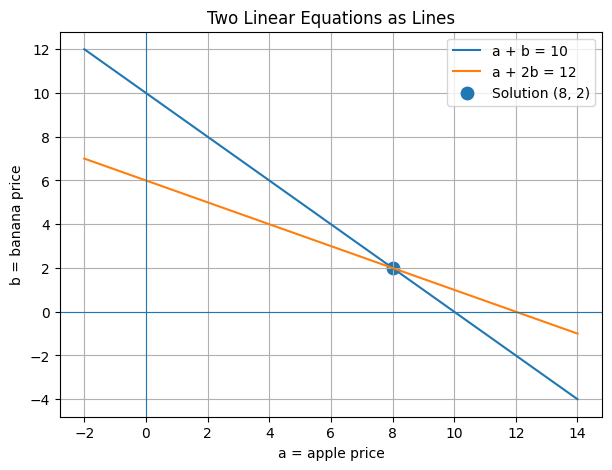

In [4]:
# Let a be the x-axis and b be the y-axis.
a_vals = np.linspace(-2, 14, 200)

# a + b = 10  -> b = 10 - a
b1 = 10 - a_vals

# a + 2b = 12 -> b = (12 - a)/2
b2 = (12 - a_vals) / 2

plt.figure(figsize=(7, 5))
plt.plot(a_vals, b1, label="a + b = 10")
plt.plot(a_vals, b2, label="a + 2b = 12")
plt.scatter([8], [2], s=80, label="Solution (8, 2)")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("a = apple price")
plt.ylabel("b = banana price")
plt.title("Two Linear Equations as Lines")
plt.grid(True)
plt.legend()
plt.show()

# 4. Three Types of Systems

A system of equations can have:

1. **One unique solution** — non-singular system
2. **Infinitely many solutions** — singular and redundant system
3. **No solution** — singular and contradictory system

In [5]:
def classify_2x2_system(A, b):
    det = np.linalg.det(A)
    rank_A = np.linalg.matrix_rank(A)
    augmented = np.column_stack([A, b])
    rank_aug = np.linalg.matrix_rank(augmented)
    
    print("A =")
    print(A)
    print("b =", b)
    print(f"det(A) = {det:.6g}")
    print(f"rank(A) = {rank_A}")
    print(f"rank([A|b]) = {rank_aug}")
    
    if abs(det) > 1e-10:
        print("Classification: Non-singular system with one unique solution.")
        print("Solution:", np.linalg.solve(A, b))
    else:
        if rank_A == rank_aug:
            print("Classification: Singular redundant system with infinitely many solutions.")
        else:
            print("Classification: Singular contradictory system with no solution.")

print("System 1: Unique solution")
classify_2x2_system(
    np.array([[1, 1], [1, 2]], dtype=float),
    np.array([10, 12], dtype=float)
)

print("\nSystem 2: Infinitely many solutions")
classify_2x2_system(
    np.array([[1, 1], [2, 2]], dtype=float),
    np.array([10, 20], dtype=float)
)

print("\nSystem 3: No solution")
classify_2x2_system(
    np.array([[1, 1], [2, 2]], dtype=float),
    np.array([10, 24], dtype=float)
)

System 1: Unique solution
A =
[[1. 1.]
 [1. 2.]]
b = [10. 12.]
det(A) = 1
rank(A) = 2
rank([A|b]) = 2
Classification: Non-singular system with one unique solution.
Solution: [8. 2.]

System 2: Infinitely many solutions
A =
[[1. 1.]
 [2. 2.]]
b = [10. 20.]
det(A) = 0
rank(A) = 1
rank([A|b]) = 1
Classification: Singular redundant system with infinitely many solutions.

System 3: No solution
A =
[[1. 1.]
 [2. 2.]]
b = [10. 24.]
det(A) = 0
rank(A) = 1
rank([A|b]) = 2
Classification: Singular contradictory system with no solution.


# 5. Determinant of a 2×2 Matrix

For a matrix:

\[
A=\begin{bmatrix}a&b\\c&d\end{bmatrix}
\]

The determinant is:

\[
\det(A)=ad-bc
\]

Important rule:

- If \(\det(A)\neq 0\), the matrix is **non-singular**.
- If \(\det(A)=0\), the matrix is **singular**.

In [6]:
def determinant_2x2(M):
    a, b = M[0]
    c, d = M[1]
    return a*d - b*c

M1 = np.array([[5, 1], [-1, 3]], dtype=float)
M2 = np.array([[2, -1], [-6, 3]], dtype=float)

for name, M in [("M1", M1), ("M2", M2)]:
    det_manual = determinant_2x2(M)
    det_numpy = np.linalg.det(M)
    print(f"{name} =")
    print(M)
    print(f"Manual determinant = {det_manual}")
    print(f"NumPy determinant  = {det_numpy:.6g}")
    print("Singular?", abs(det_numpy) < 1e-10)
    print()

M1 =
[[ 5.  1.]
 [-1.  3.]]
Manual determinant = 16.0
NumPy determinant  = 16
Singular? False

M2 =
[[ 2. -1.]
 [-6.  3.]]
Manual determinant = 0.0
NumPy determinant  = 0
Singular? True



# 6. Determinant of a 3×3 Matrix

For a 3×3 matrix, NumPy can calculate the determinant directly.

Example:

\[
A=\begin{bmatrix}
1&2&1\\
0&3&5\\
4&3&8
\end{bmatrix}
\]

In [7]:
A = np.array([
    [1, 2, 1],
    [0, 3, 5],
    [4, 3, 8]
], dtype=float)

det_A = np.linalg.det(A)
print("A =")
print(A)
print(f"det(A) = {det_A:.6g}")
print("Singular?", abs(det_A) < 1e-10)

A =
[[1. 2. 1.]
 [0. 3. 5.]
 [4. 3. 8.]]
det(A) = 37
Singular? False


## Manual 3×3 Determinant Formula

For

\[
A=\begin{bmatrix}
a&b&c\\
d&e&f\\
g&h&i
\end{bmatrix}
\]

\[
\det(A)=aei+bfg+cdh-ceg-bdi-afh
\]

In [8]:
def determinant_3x3(M):
    a, b, c = M[0]
    d, e, f = M[1]
    g, h, i = M[2]
    return a*e*i + b*f*g + c*d*h - c*e*g - b*d*i - a*f*h

manual_det = determinant_3x3(A)
print("Manual determinant:", manual_det)
print("NumPy determinant: ", round(np.linalg.det(A)))

Manual determinant: 37.0
NumPy determinant:  37


# 7. Linear Dependence and Independence

Rows are **linearly dependent** if one row can be created from the others.

Example:

\[
\begin{bmatrix}
1&0&1\\
0&1&0\\
3&2&3
\end{bmatrix}
\]

Here:

\[
3R_1+2R_2=R_3
\]

So the rows are linearly dependent.

In [9]:
M = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [3, 2, 3]
], dtype=float)

print("Matrix M:")
print(M)
print("3*Row1 + 2*Row2 =", 3*M[0] + 2*M[1])
print("Row3            =", M[2])
print("det(M) =", round(np.linalg.det(M)))
print("rank(M) =", np.linalg.matrix_rank(M))

Matrix M:
[[1. 0. 1.]
 [0. 1. 0.]
 [3. 2. 3.]]
3*Row1 + 2*Row2 = [3. 2. 3.]
Row3            = [3. 2. 3.]
det(M) = 0
rank(M) = 2


If a square matrix has linearly dependent rows, then its determinant is zero and the matrix is singular.

In [10]:
matrices = {
    "Matrix 1: dependent": np.array([[1, 0, 1], [0, 1, 0], [3, 2, 3]], dtype=float),
    "Matrix 2: dependent": np.array([[1, 1, 1], [1, 1, 2], [0, 0, -1]], dtype=float),
    "Matrix 3: independent": np.array([[1, 1, 1], [0, 2, 2], [0, 0, 3]], dtype=float),
    "Matrix 4: dependent": np.array([[1, 2, 5], [0, 3, -2], [2, 4, 10]], dtype=float),
}

for name, M in matrices.items():
    det = np.linalg.det(M)
    rank = np.linalg.matrix_rank(M)
    print(name)
    print(M)
    print(f"det = {det:.6g}")
    print(f"rank = {rank}")
    print("Classification:", "singular/dependent" if abs(det) < 1e-10 else "non-singular/independent")
    print("-" * 50)

Matrix 1: dependent
[[1. 0. 1.]
 [0. 1. 0.]
 [3. 2. 3.]]
det = 0
rank = 2
Classification: singular/dependent
--------------------------------------------------
Matrix 2: dependent
[[ 1.  1.  1.]
 [ 1.  1.  2.]
 [ 0.  0. -1.]]
det = 0
rank = 2
Classification: singular/dependent
--------------------------------------------------
Matrix 3: independent
[[1. 1. 1.]
 [0. 2. 2.]
 [0. 0. 3.]]
det = 6
rank = 3
Classification: non-singular/independent
--------------------------------------------------
Matrix 4: dependent
[[ 1.  2.  5.]
 [ 0.  3. -2.]
 [ 2.  4. 10.]]
det = 0
rank = 2
Classification: singular/dependent
--------------------------------------------------


# 8. Solving a 3×3 System

Example from the lesson:

- Day 1: apple + banana + cherry = 10
- Day 2: apple + 2 bananas + cherry = 15
- Day 3: apple + banana + 2 cherries = 12

Let:

\[
a = \text{apple price},\quad b=\text{banana price},\quad c=\text{cherry price}
\]

System:

\[
\begin{cases}
a+b+c=10\\
a+2b+c=15\\
a+b+2c=12
\end{cases}
\]

In [11]:
A = np.array([
    [1, 1, 1],
    [1, 2, 1],
    [1, 1, 2]
], dtype=float)

b = np.array([10, 15, 12], dtype=float)

solution = np.linalg.solve(A, b)
print("[apple, banana, cherry] =", solution)
print(f"Apple:  ${solution[0]:.2f}")
print(f"Banana: ${solution[1]:.2f}")
print(f"Cherry: ${solution[2]:.2f}")

[apple, banana, cherry] = [3. 5. 2.]
Apple:  $3.00
Banana: $5.00
Cherry: $2.00


# 9. Constants Do Not Determine Singularity

The coefficient matrix determines whether a square system is singular or non-singular.

The constants on the right-hand side affect whether a singular system has:

- infinitely many solutions, or
- no solution.

But singularity is determined by the coefficient matrix.

In [12]:
# Same coefficient matrix, different constants
A = np.array([
    [1, 1, 1],
    [1, 1, 2],
    [1, 1, 3]
], dtype=float)

b_redundant = np.array([10, 15, 20], dtype=float)
b_contradictory = np.array([10, 15, 18], dtype=float)

for label, b in [("Redundant/infinite case", b_redundant), ("Contradictory/no solution case", b_contradictory)]:
    rank_A = np.linalg.matrix_rank(A)
    rank_aug = np.linalg.matrix_rank(np.column_stack([A, b]))
    det = np.linalg.det(A)
    print(label)
    print("det(A) =", round(det))
    print("rank(A) =", rank_A)
    print("rank([A|b]) =", rank_aug)
    if rank_A == rank_aug:
        print("Result: consistent system, infinitely many solutions because rank < number of variables")
    else:
        print("Result: inconsistent system, no solution")
    print("-" * 60)

Redundant/infinite case
det(A) = 0
rank(A) = 2
rank([A|b]) = 2
Result: consistent system, infinitely many solutions because rank < number of variables
------------------------------------------------------------
Contradictory/no solution case
det(A) = 0
rank(A) = 2
rank([A|b]) = 3
Result: inconsistent system, no solution
------------------------------------------------------------


# 10. Row Reduction with SymPy

Row reduction changes a matrix into a simpler form while preserving its solution structure.

The reduced row echelon form helps us see:

- pivots
- rank
- free variables
- whether the system has one, none, or infinitely many solutions

In [13]:
!pip install sympy

In [14]:
if sympy_available:
    A = sp.Matrix([
        [1, 1, 1],
        [1, 2, 1],
        [1, 1, 2]
    ])
    b = sp.Matrix([10, 15, 12])
    augmented = A.row_join(b)
    
    print("Augmented matrix:")
    display(augmented)
    
    print("Reduced row echelon form:")
    rref_matrix, pivot_columns = augmented.rref()
    display(rref_matrix)
    print("Pivot columns:", pivot_columns)
else:
    print("SymPy is not available in this environment.")

Augmented matrix:


Matrix([
[1, 1, 1, 10],
[1, 2, 1, 15],
[1, 1, 2, 12]])

Reduced row echelon form:


Matrix([
[1, 0, 0, 3],
[0, 1, 0, 5],
[0, 0, 1, 2]])

Pivot columns: (0, 1, 2)


# 11. Practice: Check Your Knowledge

## Problem 1

Bob has a mixture of apples and oranges of the same size, split into two bags.

- Bag 1: 4 apples and 3 oranges weighs 700g.
- Bag 2: 2 apples and 6 oranges weighs 1000g.

Let:

\[
a = \text{weight of one apple}
\]

\[
o = \text{weight of one orange}
\]

Write and solve the system.

In [18]:
A = np.array([
    [4, 3],
    [2, 6]
], dtype=float)

b = np.array([700, 1000], dtype=float)

solution = np.linalg.solve(A, b)
apple_weight, orange_weight = solution
print(f"One apple weighs  {apple_weight:.2f} grams")
print(f"One orange weighs {orange_weight:.2f} grams")

One apple weighs  66.67 grams
One orange weighs 144.44 grams


## Problem 2

Convert this system to matrix form and solve:

\[
\begin{cases}
5x + 3y + 5z = 6\\
7x + 2y + 8z = 17\\
4x + 3z = 8
\end{cases}
\]

In [19]:
A = np.array([
    [5, 3, 5],
    [7, 2, 8],
    [4, 0, 3]
], dtype=float)

b = np.array([6, 17, 8], dtype=float)

print("Coefficient matrix A:")
print(A)
print("Target vector b:")
print(b)
print("Solution [x, y, z]:")
print(np.linalg.solve(A, b))

Coefficient matrix A:
[[5. 3. 5.]
 [7. 2. 8.]
 [4. 0. 3.]]
Target vector b:
[ 6. 17.  8.]
Solution [x, y, z]:
[-0.2173913  -2.56521739  2.95652174]


## Problem 3

Compute the determinant and decide whether this matrix is singular or non-singular:

\[
\begin{bmatrix}
1&2&1\\
0&3&5\\
4&3&8
\end{bmatrix}
\]

In [20]:
M = np.array([
    [1, 2, 1],
    [0, 3, 5],
    [4, 3, 8]
], dtype=float)

det = np.linalg.det(M)
print("det(M) =", round(det))
print("The matrix is", "singular" if abs(det) < 1e-10 else "non-singular")

det(M) = 37
The matrix is non-singular


# 12. Quick Reference Summary

| Concept | Meaning |
|---|---|
| Linear equation | An equation where variables are only multiplied by constants and added/subtracted |
| System of equations | A group of equations solved together |
| Matrix | A rectangular arrangement of numbers |
| Vector | A list of numbers |
| Determinant | A number that helps identify whether a square matrix is singular |
| Singular matrix | Determinant is zero; no unique solution |
| Non-singular matrix | Determinant is nonzero; unique solution |
| Linear dependence | One row/vector can be made from others |
| Linear independence | No row/vector can be made from the others |
| Rank | Number of independent rows or columns |

# 13. Final Notes

For machine learning, linear algebra matters because data and models are often represented using:

- matrices of features
- vectors of weights
- systems of equations
- transformations
- determinants and ranks to understand structure

A linear regression model can be written compactly as:

\[
Xw = y
\]

or with bias:

\[
Xw+b=y
\]

This is why systems of linear equations are foundational for machine learning.